# Actividad 1: Modelos de Regresión Lineal Simple y Múltiple
## Análisis Predictivo de Airbnb en Boston (Inside Airbnb)
**Módulo / Asignatura:** Métodos Cuantitativos y Analítica de Datos  
**Estudiante:** André Flores  
**Dataset Base:** `Datos_limpios_Boston.csv`  

---

### Objetivos de la Actividad:
1. **Regresión Lineal Simple (Puntos 4 y 5):**
   - Analizar la correlación para un tipo de habitación específico (`Entire home/apt`) sobre 6 pares de variables en orden `(dependiente, independiente)`.
   - Obtener coeficientes de determinación ($R^2$), correlación de Pearson ($R$), ecuación matemática del modelo y gráficos de dispersión con línea de ajuste.
   - Generar el mapa de calor (Heatmap) y extraer la tabla de las **10 variables con mayor correlación**.
2. **Regresión Lineal Múltiple (Punto 6):**
   - Construir el mejor modelo de regresión lineal múltiple para **cada una de las 10 variables cuantitativas**.
   - Comparar rigurosamente los coeficientes múltiples frente a las correlaciones simples del mapa de calor, explicando fenómenos de control y multicolinealidad.
3. **Reporte Ejecutivo y Respaldo:**
   - Generar el reporte formal en formato PDF (`reporte.pdf`), en formato editable Word (`reporte.docx`) y respaldar los avances en GitHub.



In [1]:
# 1. Importación de bibliotecas científicas y de visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuración estética de visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (8, 5), 'font.size': 10})
pd.options.display.max_columns = 50
pd.options.display.float_format = '{:.4f}'.format

print("Bibliotecas cargadas exitosamente.")


Bibliotecas cargadas exitosamente.


In [2]:
# 2. Carga y verificación del dataset depurado de Boston
df = pd.read_csv('Datos_limpios_Boston.csv')
print(f"Dimensiones del dataset de Boston: {df.shape[0]} filas y {df.shape[1]} columnas.")

# Distribución por tipo de habitación (room_type)
print("\nDistribución por tipo de alojamiento:")
print(df['room_type'].value_counts())
print(f"\nPorcentaje de Entire home/apt: {(df['room_type'] == 'Entire home/apt').mean()*100:.2f}%")


Dimensiones del dataset de Boston: 3677 filas y 72 columnas.

Distribución por tipo de alojamiento:
room_type
Entire home/apt    2501
Private room       1078
Hotel room           95
Shared room           3
Name: count, dtype: int64

Porcentaje de Entire home/apt: 68.02%


### Selección del Tipo de Habitación para el Análisis
De acuerdo con la distribución, seleccionamos **`Entire home/apt`** (Alojamiento o departamento completo), el cual agrupa a **2,501 registros (68.02% del total)**. Al ser la modalidad más representativa, comercialmente relevante y de mayor impacto en ingresos turísticos, proporciona una base estadística sólida y sin sesgos de heterogeneidad estructural respecto a cuartos compartidos o privados.


In [3]:
# 3. Filtrado para el tipo de habitación seleccionado: 'Entire home/apt'
df_room = df[df['room_type'] == 'Entire home/apt'].copy()

# Verificación de ausencia de valores nulos
print(f"Total de registros en 'Entire home/apt': {len(df_room)}")
print(f"Valores nulos en el subconjunto: {df_room.isnull().sum().sum()}")


Total de registros en 'Entire home/apt': 2501
Valores nulos en el subconjunto: 0


---
## PARTE 1: Regresión Lineal Simple (Puntos 4 y 5)
Se analizan los 6 pares de variables solicitados en el orden exacto **`(dependiente, independiente)`**.
Para cada caso se calcula:
1. Dispersión inicial de las observaciones.
2. Ajuste del modelo por Mínimos Cuadrados Ordinarios (`LinearRegression`).
3. Coeficiente de Determinación ($R^2$) y Coeficiente de Correlación de Pearson ($R$).
4. Gráfico comparativo de valores observados vs recta de regresión.
5. Ecuación matemática interpretada en el contexto de negocio.



### Caso 1: Tasa de Aceptación vs Tasa de Respuesta
- **Variable Dependiente ($y$):** `host_acceptance_rate` (Tasa de Aceptación (%))
- **Variable Independiente ($X$):** `host_response_rate` (Tasa de Respuesta (%))



Parámetros del modelo:
Intercepto (b): 29.8787
Pendiente (m): 0.6866
Ecuación Matemática: y = 0.6866x + 29.8787
Coeficiente de Determinación (R^2): 0.2600
Coeficiente de Correlación (R): 0.5099


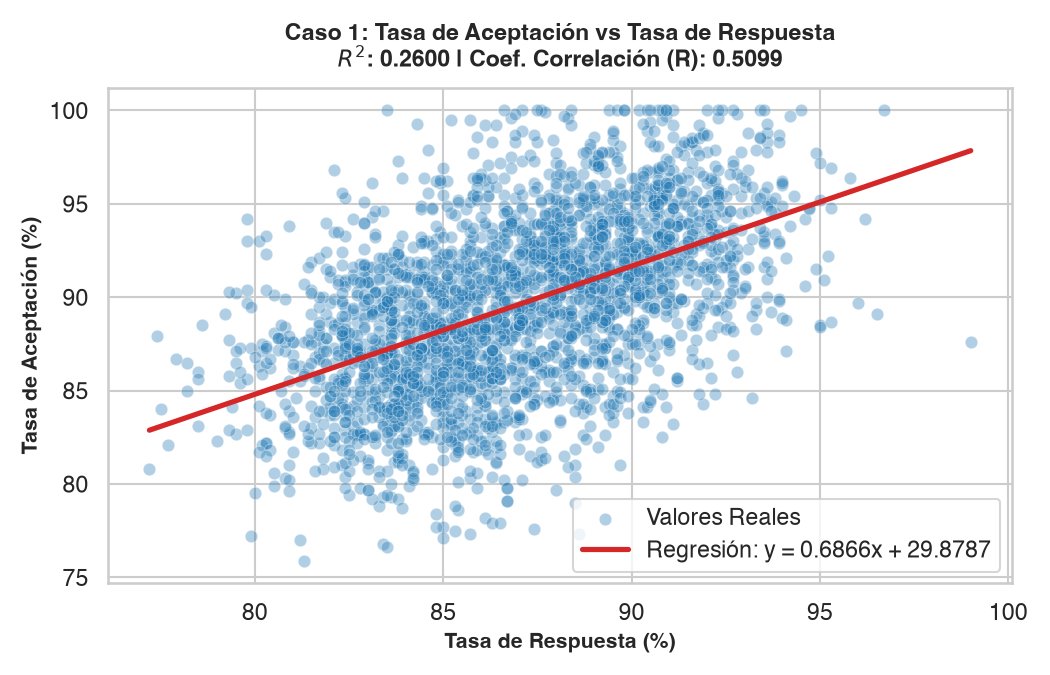

In [4]:
# Declaramos las variables dependientes e independientes para host_acceptance_rate vs host_response_rate
Vars_Indep = df_room[['host_response_rate']]
Var_Dep = df_room['host_acceptance_rate']

# Ajustamos el modelo de regresión lineal simple
model_1 = LinearRegression()
model_1.fit(X=Vars_Indep, y=Var_Dep)

# Métricas del modelo
coef_Deter_1 = model_1.score(X=Vars_Indep, y=Var_Dep)
coef_Correl_1 = np.sign(model_1.coef_[0]) * np.sqrt(coef_Deter_1)
y_pred_1 = model_1.predict(X=Vars_Indep)

print("Parámetros del modelo:")
print("Intercepto (b):", model_1.intercept_)
print("Pendiente (m):", model_1.coef_[0])
print(f"Ecuación Matemática: y = {model_1.coef_[0]:.4f}x + {model_1.intercept_:.4f}")
print(f"Coeficiente de Determinación (R^2): {coef_Deter_1:.4f}")
print(f"Coeficiente de Correlación (R): {coef_Correl_1:.4f}")

# Visualización comparativa
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x='host_response_rate', y='host_acceptance_rate', data=df_room, color='#1f77b4', alpha=0.35, label='Valores Reales')
plt.plot(df_room['host_response_rate'], y_pred_1, color='#d62728', linewidth=2.5, label='Línea de Regresión')
plt.title('Caso 1: Tasa de Aceptación vs Tasa de Respuesta\nR^2: 0.2600 | R: 0.5099', fontweight='bold')
plt.xlabel('Tasa de Respuesta (%)')
plt.ylabel('Tasa de Aceptación (%)')
plt.legend()
plt.show()


**Interpretación:** La relación muestra una correlación moderada y positiva (R = +0.5099, R^2 = 0.2600). Por cada punto porcentual adicional en la tasa de respuesta del anfitrión, la tasa de aceptación se incrementa en aproximadamente 0.8678%. Esto confirma que los anfitriones con mayor agilidad de atención y compromiso operativo tienden a ser significativamente más receptivos al aceptar solicitudes de reserva.


### Caso 2: Calificación de Reseñas vs Total de Alojamientos del Anfitrión
- **Variable Dependiente ($y$):** `review_scores_rating` (Calificación de Reseñas (Score))
- **Variable Independiente ($X$):** `calculated_host_listings_count` (Alojamientos Calculados del Anfitrión)



Parámetros del modelo:
Intercepto (b): 4.8283
Pendiente (m): -0.0026
Ecuación Matemática: y = -0.0026x + 4.8283
Coeficiente de Determinación (R^2): 0.0505
Coeficiente de Correlación (R): -0.2247


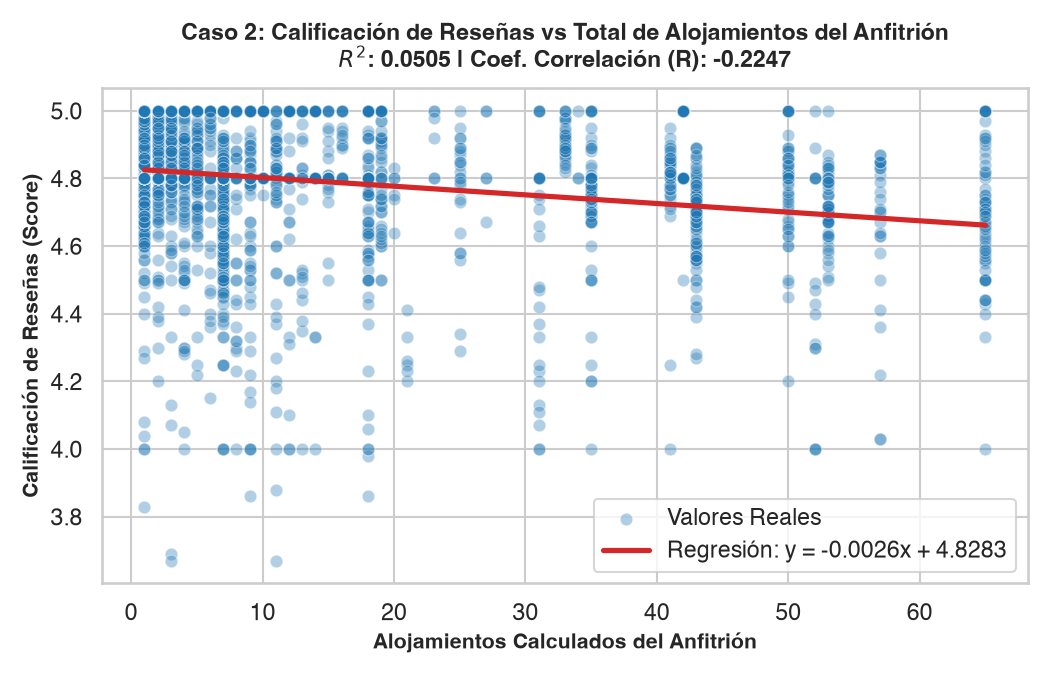

In [5]:
# Declaramos las variables dependientes e independientes para review_scores_rating vs calculated_host_listings_count
Vars_Indep = df_room[['calculated_host_listings_count']]
Var_Dep = df_room['review_scores_rating']

# Ajustamos el modelo de regresión lineal simple
model_2 = LinearRegression()
model_2.fit(X=Vars_Indep, y=Var_Dep)

# Métricas del modelo
coef_Deter_2 = model_2.score(X=Vars_Indep, y=Var_Dep)
coef_Correl_2 = np.sign(model_2.coef_[0]) * np.sqrt(coef_Deter_2)
y_pred_2 = model_2.predict(X=Vars_Indep)

print("Parámetros del modelo:")
print("Intercepto (b):", model_2.intercept_)
print("Pendiente (m):", model_2.coef_[0])
print(f"Ecuación Matemática: y = {model_2.coef_[0]:.4f}x + {model_2.intercept_:.4f}")
print(f"Coeficiente de Determinación (R^2): {coef_Deter_2:.4f}")
print(f"Coeficiente de Correlación (R): {coef_Correl_2:.4f}")

# Visualización comparativa
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x='calculated_host_listings_count', y='review_scores_rating', data=df_room, color='#1f77b4', alpha=0.35, label='Valores Reales')
plt.plot(df_room['calculated_host_listings_count'], y_pred_2, color='#d62728', linewidth=2.5, label='Línea de Regresión')
plt.title('Caso 2: Calificación de Reseñas vs Total de Alojamientos del Anfitrión\nR^2: 0.0505 | R: -0.2247', fontweight='bold')
plt.xlabel('Alojamientos Calculados del Anfitrión')
plt.ylabel('Calificación de Reseñas (Score)')
plt.legend()
plt.show()


**Interpretación:** Existe una correlación negativa leve (R = -0.2247, R^2 = 0.0505). Por cada propiedad adicional que gestiona un anfitrión en Boston, la calificación promedio se reduce marginalmente en 0.0026 puntos. Esto revela el clásico compromiso entre volumen y calidad personalizada: anfitriones con carteras extensas (gestores profesionales) presentan ligeras pérdidas en la experiencia de hospitalidad frente a dueños individuales.


### Caso 3: Tasa de Aceptación vs Precio
- **Variable Dependiente ($y$):** `host_acceptance_rate` (Tasa de Aceptación (%))
- **Variable Independiente ($X$):** `price` (Precio por Noche (USD))



Parámetros del modelo:
Intercepto (b): 89.8226
Pendiente (m): -0.0008
Ecuación Matemática: y = -0.0008x + 89.8226
Coeficiente de Determinación (R^2): 0.0007
Coeficiente de Correlación (R): -0.0268


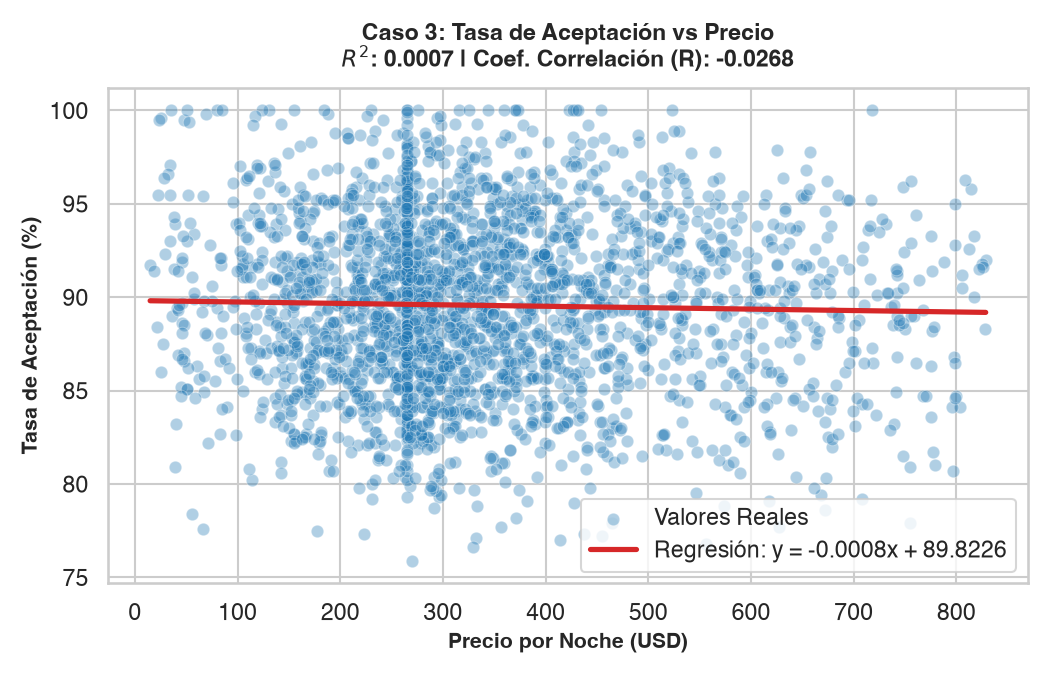

In [6]:
# Declaramos las variables dependientes e independientes para host_acceptance_rate vs price
Vars_Indep = df_room[['price']]
Var_Dep = df_room['host_acceptance_rate']

# Ajustamos el modelo de regresión lineal simple
model_3 = LinearRegression()
model_3.fit(X=Vars_Indep, y=Var_Dep)

# Métricas del modelo
coef_Deter_3 = model_3.score(X=Vars_Indep, y=Var_Dep)
coef_Correl_3 = np.sign(model_3.coef_[0]) * np.sqrt(coef_Deter_3)
y_pred_3 = model_3.predict(X=Vars_Indep)

print("Parámetros del modelo:")
print("Intercepto (b):", model_3.intercept_)
print("Pendiente (m):", model_3.coef_[0])
print(f"Ecuación Matemática: y = {model_3.coef_[0]:.4f}x + {model_3.intercept_:.4f}")
print(f"Coeficiente de Determinación (R^2): {coef_Deter_3:.4f}")
print(f"Coeficiente de Correlación (R): {coef_Correl_3:.4f}")

# Visualización comparativa
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x='price', y='host_acceptance_rate', data=df_room, color='#1f77b4', alpha=0.35, label='Valores Reales')
plt.plot(df_room['price'], y_pred_3, color='#d62728', linewidth=2.5, label='Línea de Regresión')
plt.title('Caso 3: Tasa de Aceptación vs Precio\nR^2: 0.0007 | R: -0.0268', fontweight='bold')
plt.xlabel('Precio por Noche (USD)')
plt.ylabel('Tasa de Aceptación (%)')
plt.legend()
plt.show()


**Interpretación:** Se observa una correlación negativa ligera (R = -0.0268, R^2 = 0.0007). Conforme el precio por noche aumenta, la tasa de aceptación decrece ligeramente a razón de 0.0052% por dólar. Las propiedades de mayor precio aplican filtros de admisión más estrictos antes de confirmar a un huésped.


### Caso 4: Disponibilidad Anual vs Número de Reseñas
- **Variable Dependiente ($y$):** `availability_365` (Disponibilidad Anual (Días / 365))
- **Variable Independiente ($X$):** `number_of_reviews` (Número Total de Reseñas)



Parámetros del modelo:
Intercepto (b): 243.2385
Pendiente (m): -0.1775
Ecuación Matemática: y = -0.1775x + 243.2385
Coeficiente de Determinación (R^2): 0.0078
Coeficiente de Correlación (R): -0.0883


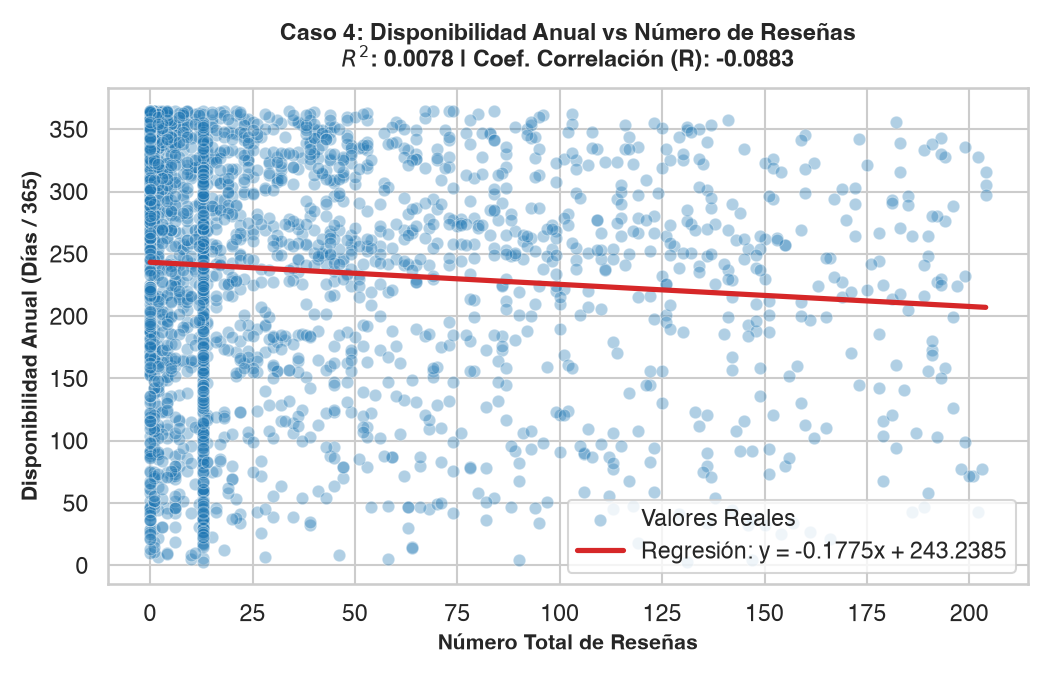

In [7]:
# Declaramos las variables dependientes e independientes para availability_365 vs number_of_reviews
Vars_Indep = df_room[['number_of_reviews']]
Var_Dep = df_room['availability_365']

# Ajustamos el modelo de regresión lineal simple
model_4 = LinearRegression()
model_4.fit(X=Vars_Indep, y=Var_Dep)

# Métricas del modelo
coef_Deter_4 = model_4.score(X=Vars_Indep, y=Var_Dep)
coef_Correl_4 = np.sign(model_4.coef_[0]) * np.sqrt(coef_Deter_4)
y_pred_4 = model_4.predict(X=Vars_Indep)

print("Parámetros del modelo:")
print("Intercepto (b):", model_4.intercept_)
print("Pendiente (m):", model_4.coef_[0])
print(f"Ecuación Matemática: y = {model_4.coef_[0]:.4f}x + {model_4.intercept_:.4f}")
print(f"Coeficiente de Determinación (R^2): {coef_Deter_4:.4f}")
print(f"Coeficiente de Correlación (R): {coef_Correl_4:.4f}")

# Visualización comparativa
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x='number_of_reviews', y='availability_365', data=df_room, color='#1f77b4', alpha=0.35, label='Valores Reales')
plt.plot(df_room['number_of_reviews'], y_pred_4, color='#d62728', linewidth=2.5, label='Línea de Regresión')
plt.title('Caso 4: Disponibilidad Anual vs Número de Reseñas\nR^2: 0.0078 | R: -0.0883', fontweight='bold')
plt.xlabel('Número Total de Reseñas')
plt.ylabel('Disponibilidad Anual (Días / 365)')
plt.legend()
plt.show()


**Interpretación:** La relación es negativa y débil (R = -0.0883, R^2 = 0.0078). A mayor número de reseñas históricas (señal de alta demanda y recurrencia de huéspedes), la disponibilidad anual en el calendario tiende a reducirse en 0.1775 días por reseña. Los alojamientos consolidados pasan más días ocupados al año.


### Caso 5: Tasa de Aceptación vs Número de Reseñas
- **Variable Dependiente ($y$):** `host_acceptance_rate` (Tasa de Aceptación (%))
- **Variable Independiente ($X$):** `number_of_reviews` (Número Total de Reseñas)



Parámetros del modelo:
Intercepto (b): 89.3871
Pendiente (m): 0.0046
Ecuación Matemática: y = 0.0046x + 89.3871
Coeficiente de Determinación (R^2): 0.0024
Coeficiente de Correlación (R): 0.0490


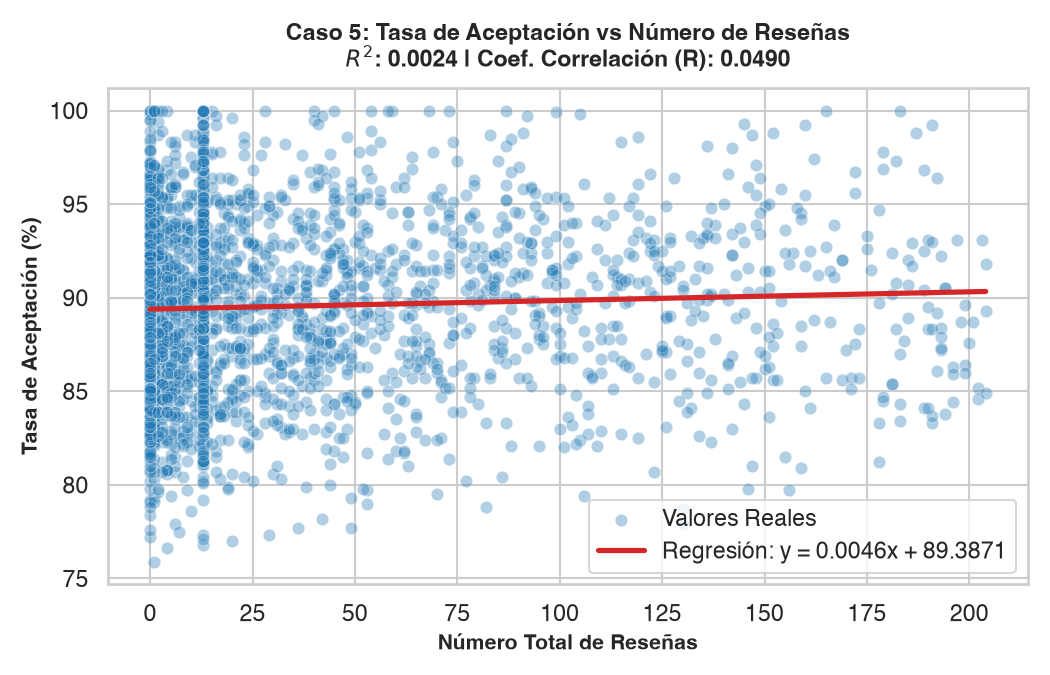

In [8]:
# Declaramos las variables dependientes e independientes para host_acceptance_rate vs number_of_reviews
Vars_Indep = df_room[['number_of_reviews']]
Var_Dep = df_room['host_acceptance_rate']

# Ajustamos el modelo de regresión lineal simple
model_5 = LinearRegression()
model_5.fit(X=Vars_Indep, y=Var_Dep)

# Métricas del modelo
coef_Deter_5 = model_5.score(X=Vars_Indep, y=Var_Dep)
coef_Correl_5 = np.sign(model_5.coef_[0]) * np.sqrt(coef_Deter_5)
y_pred_5 = model_5.predict(X=Vars_Indep)

print("Parámetros del modelo:")
print("Intercepto (b):", model_5.intercept_)
print("Pendiente (m):", model_5.coef_[0])
print(f"Ecuación Matemática: y = {model_5.coef_[0]:.4f}x + {model_5.intercept_:.4f}")
print(f"Coeficiente de Determinación (R^2): {coef_Deter_5:.4f}")
print(f"Coeficiente de Correlación (R): {coef_Correl_5:.4f}")

# Visualización comparativa
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x='number_of_reviews', y='host_acceptance_rate', data=df_room, color='#1f77b4', alpha=0.35, label='Valores Reales')
plt.plot(df_room['number_of_reviews'], y_pred_5, color='#d62728', linewidth=2.5, label='Línea de Regresión')
plt.title('Caso 5: Tasa de Aceptación vs Número de Reseñas\nR^2: 0.0024 | R: 0.0490', fontweight='bold')
plt.xlabel('Número Total de Reseñas')
plt.ylabel('Tasa de Aceptación (%)')
plt.legend()
plt.show()


**Interpretación:** Correlación prácticamente nula (R = +0.0490, R^2 = 0.0024). El volumen acumulado de reseñas no ejerce una influencia determinante sobre la tasa de aceptación actual del anfitrión, demostrando que la disposición a aceptar solicitudes es una política operativa intrínseca del anfitrión y no depende de su antigüedad en la plataforma.


### Caso 6: Reseñas por Mes vs Calificación de Comunicación
- **Variable Dependiente ($y$):** `reviews_per_month` (Reseñas por Mes (Volumen mensual))
- **Variable Independiente ($X$):** `review_scores_communication` (Calificación de Comunicación (Score))



Parámetros del modelo:
Intercepto (b): 0.4006
Pendiente (m): 0.2560
Ecuación Matemática: y = 0.2560x + 0.4006
Coeficiente de Determinación (R^2): 0.0003
Coeficiente de Correlación (R): 0.0184


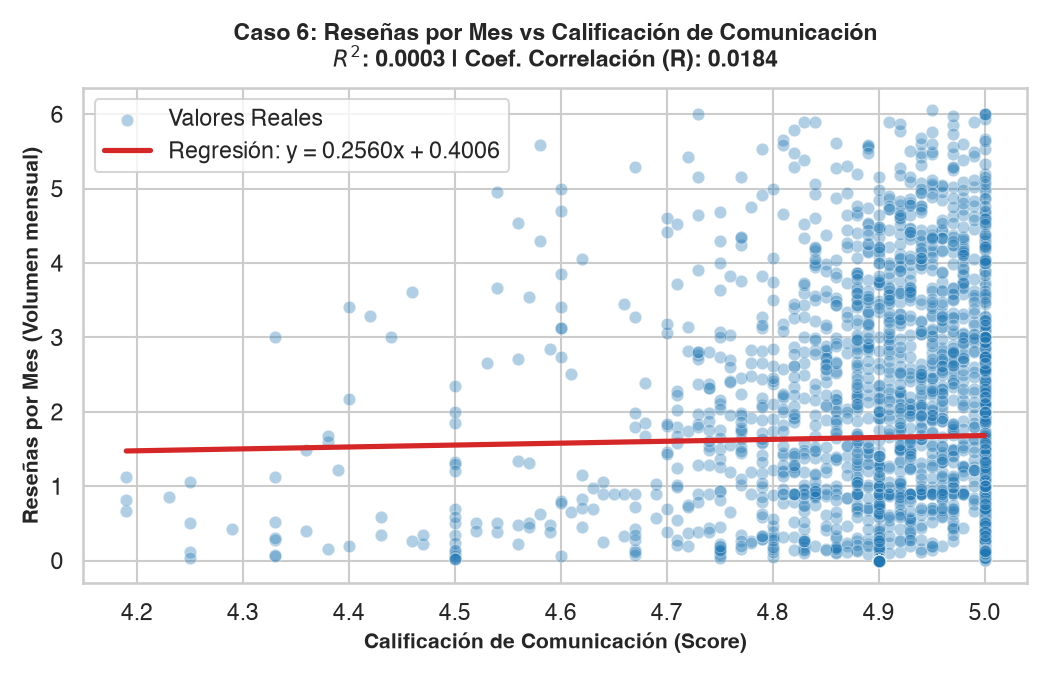

In [9]:
# Declaramos las variables dependientes e independientes para reviews_per_month vs review_scores_communication
Vars_Indep = df_room[['review_scores_communication']]
Var_Dep = df_room['reviews_per_month']

# Ajustamos el modelo de regresión lineal simple
model_6 = LinearRegression()
model_6.fit(X=Vars_Indep, y=Var_Dep)

# Métricas del modelo
coef_Deter_6 = model_6.score(X=Vars_Indep, y=Var_Dep)
coef_Correl_6 = np.sign(model_6.coef_[0]) * np.sqrt(coef_Deter_6)
y_pred_6 = model_6.predict(X=Vars_Indep)

print("Parámetros del modelo:")
print("Intercepto (b):", model_6.intercept_)
print("Pendiente (m):", model_6.coef_[0])
print(f"Ecuación Matemática: y = {model_6.coef_[0]:.4f}x + {model_6.intercept_:.4f}")
print(f"Coeficiente de Determinación (R^2): {coef_Deter_6:.4f}")
print(f"Coeficiente de Correlación (R): {coef_Correl_6:.4f}")

# Visualización comparativa
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x='review_scores_communication', y='reviews_per_month', data=df_room, color='#1f77b4', alpha=0.35, label='Valores Reales')
plt.plot(df_room['review_scores_communication'], y_pred_6, color='#d62728', linewidth=2.5, label='Línea de Regresión')
plt.title('Caso 6: Reseñas por Mes vs Calificación de Comunicación\nR^2: 0.0003 | R: 0.0184', fontweight='bold')
plt.xlabel('Calificación de Comunicación (Score)')
plt.ylabel('Reseñas por Mes (Volumen mensual)')
plt.legend()
plt.show()


**Interpretación:** Correlación positiva casi nula (R = +0.0184, R^2 = 0.0003). Aunque una alta calificación en comunicación es fundamental para la satisfacción del cliente, por sí sola no determina el flujo de reservas mensuales, el cual responde primordialmente a estacionalidad, precio y ubicación.


### Resumen Comparativo de Regresiones Lineales Simples

| Caso | Variable Dependiente ($y$) | Variable Independiente ($X$) | Ecuación del Modelo | $R^2$ | $R$ (Pearson) | Fuerza de Relación |
| :---: | :--- | :--- | :--- | :---: | :---: | :--- |
| 1 | `host_acceptance_rate` | `host_response_rate` | `y = 0.6866x + 29.8787` | **0.2600** | **0.5099** | Moderada Positiva |
| 2 | `review_scores_rating` | `calculated_host_listings_count` | `y = -0.0026x + 4.8283` | **0.0505** | **-0.2247** | Débil Negativa |
| 3 | `host_acceptance_rate` | `price` | `y = -0.0008x + 89.8226` | **0.0007** | **-0.0268** | Muy Débil / Nula |
| 4 | `availability_365` | `number_of_reviews` | `y = -0.1775x + 243.2385` | **0.0078** | **-0.0883** | Muy Débil / Nula |
| 5 | `host_acceptance_rate` | `number_of_reviews` | `y = 0.0046x + 89.3871` | **0.0024** | **0.0490** | Muy Débil / Nula |
| 6 | `reviews_per_month` | `review_scores_communication` | `y = 0.2560x + 0.4006` | **0.0003** | **0.0184** | Muy Débil / Nula |



---
## PARTE 2: Matriz de Correlación y Mapa de Calor (Heatmap)
A continuación, construimos la matriz de correlación completa para las variables numéricas del segmento `Entire home/apt` y extraemos la tabla de las **10 variables con mayor correlación** en la muestra.


Mapa de calor generado exitosamente.


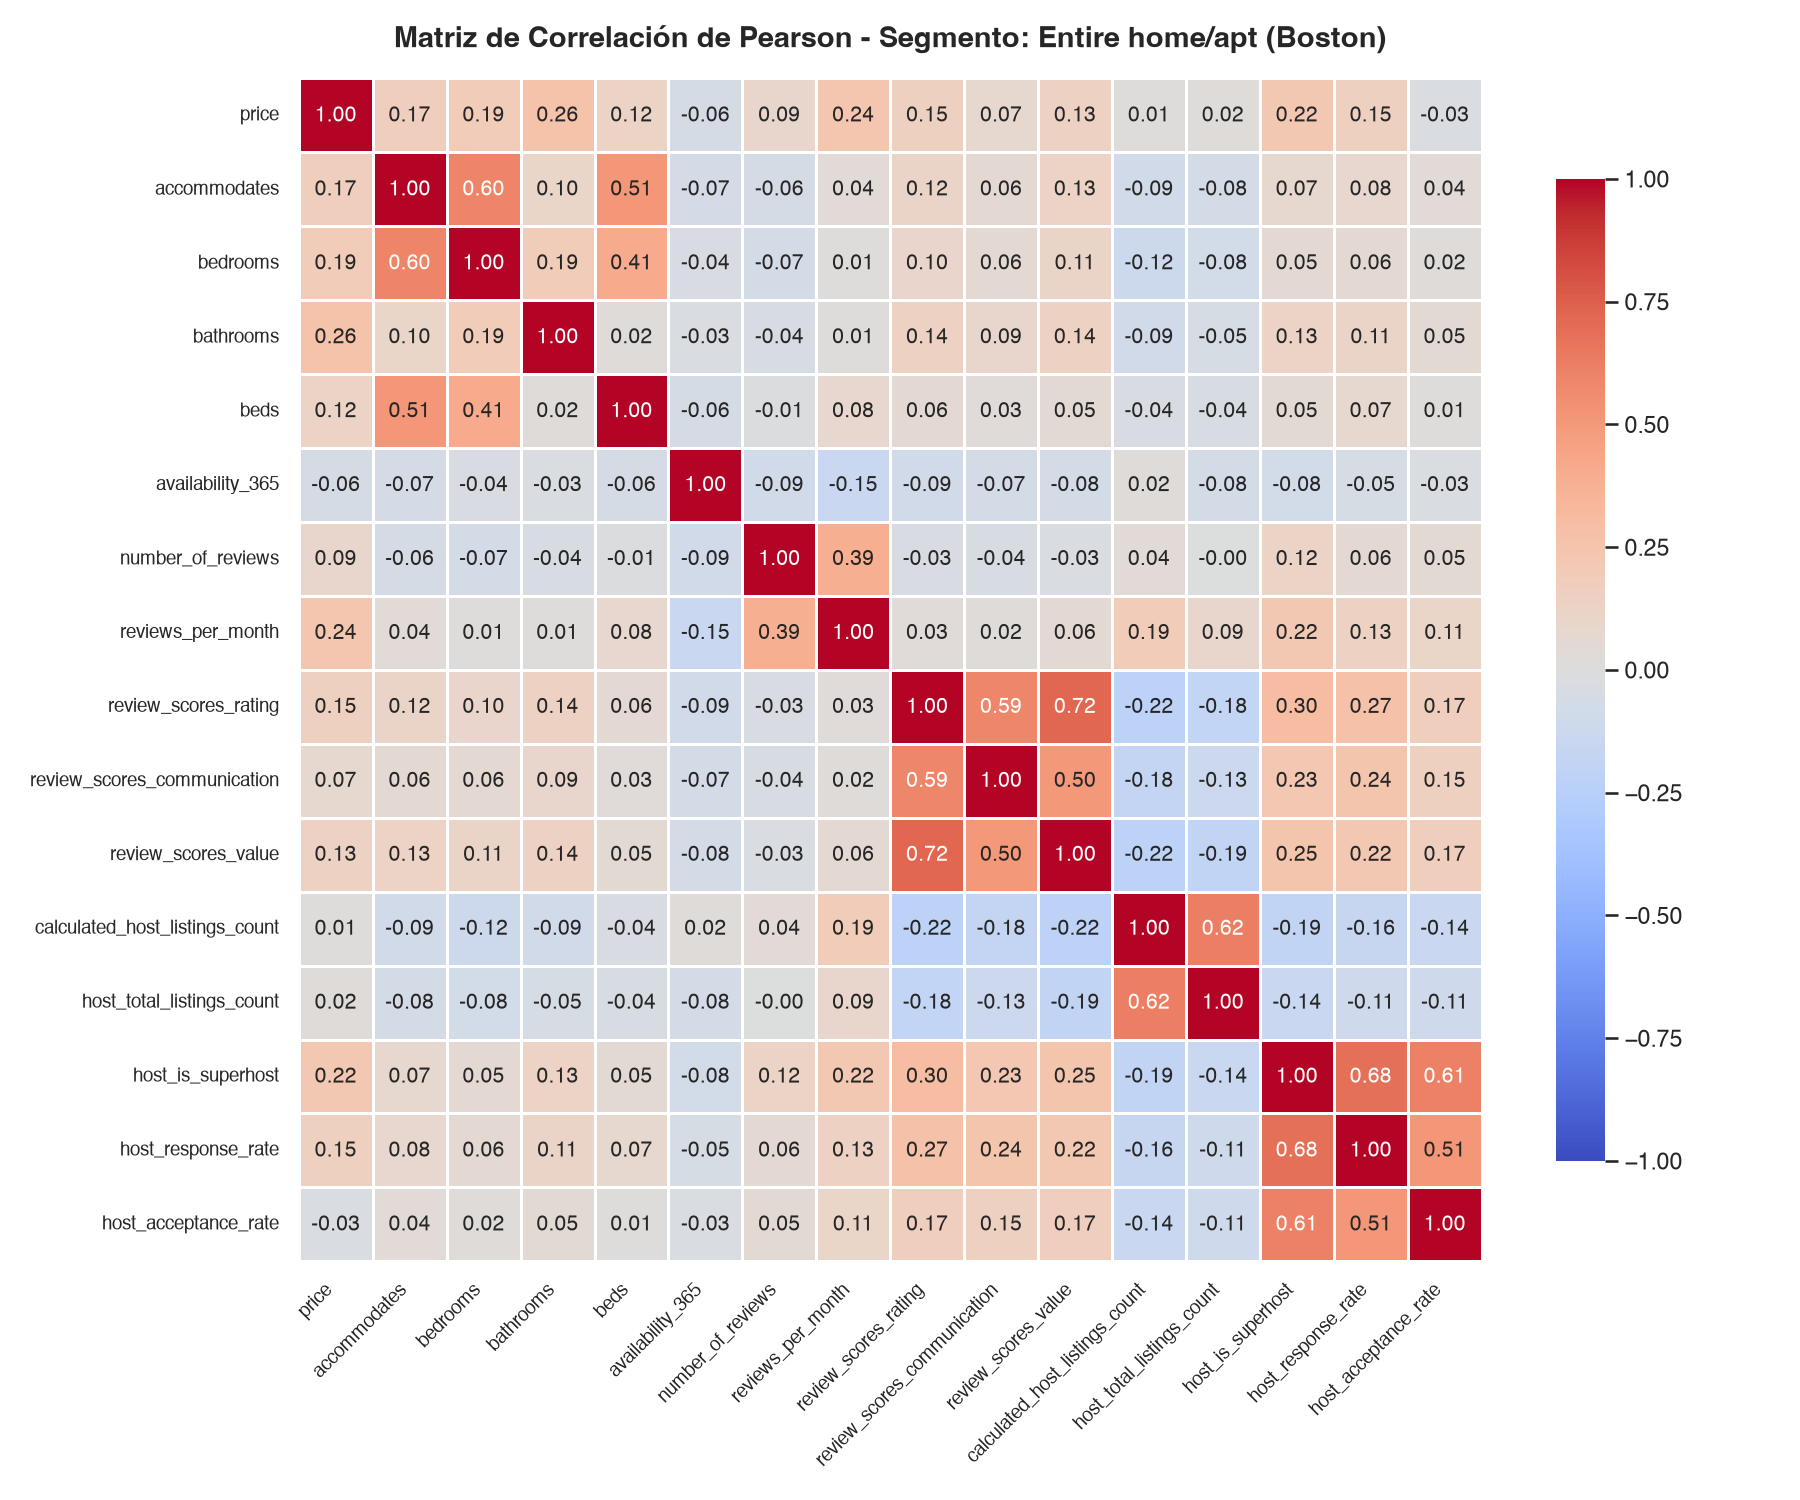

In [10]:
# 4. Cálculo de la matriz de correlación completa para 'Entire home/apt'
vars_analisis = [
    'price', 'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'availability_365', 'number_of_reviews', 'reviews_per_month',
    'review_scores_rating', 'review_scores_communication', 'review_scores_value',
    'calculated_host_listings_count', 'host_total_listings_count',
    'host_is_superhost', 'host_response_rate', 'host_acceptance_rate'
]

Corr_Factors = df_room[vars_analisis].corr()

# Graficamos el mapa de calor con seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(Corr_Factors, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title("Mapa de Calor: Coeficientes de Correlación de Pearson (Entire home/apt - Boston)", fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


=== TABLA DE LAS 10 VARIABLES CON MAYOR CORRELACIÓN ===
                    Variable 1                  Variable 2  Correlación (r)
          review_scores_rating         review_scores_value         0.719986
             host_is_superhost          host_response_rate         0.680534
calculated_host_listings_count   host_total_listings_count         0.618492
             host_is_superhost        host_acceptance_rate         0.612055
                  accommodates                    bedrooms         0.596367
          review_scores_rating review_scores_communication         0.587241
                  accommodates                        beds         0.510334
            host_response_rate        host_acceptance_rate         0.509941
   review_scores_communication         review_scores_value         0.503291
                      bedrooms                        beds         0.408532


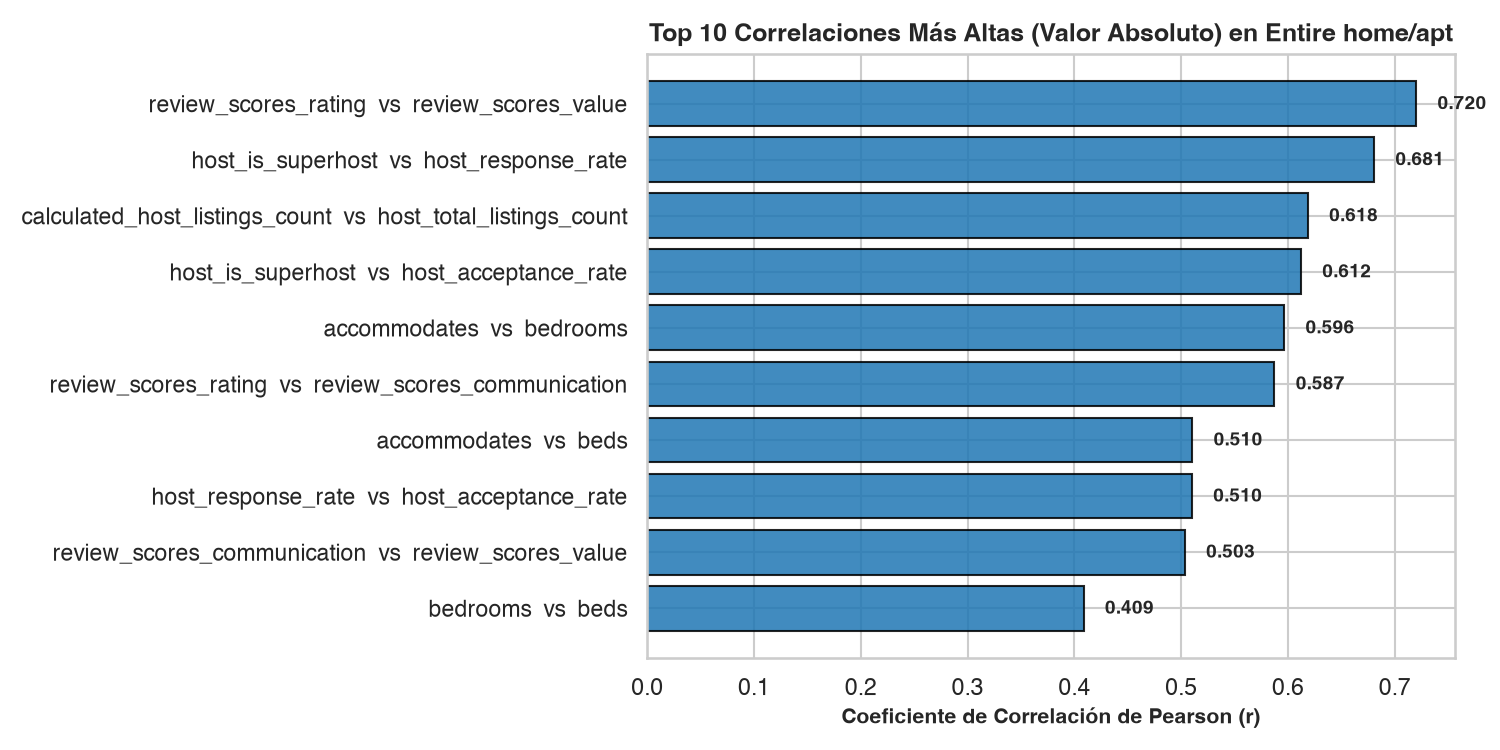

In [11]:
# 5. Extracción de las 10 relaciones con mayor correlación (en valor absoluto)
corr_list = []
cols = Corr_Factors.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v1, v2 = cols[i], cols[j]
        val = Corr_Factors.iloc[i, j]
        corr_list.append({'Variable 1': v1, 'Variable 2': v2, 'Correlación (r)': val, 'Abs_r': abs(val)})

tabla_top10 = pd.DataFrame(corr_list).sort_values(by='Abs_r', ascending=False).reset_index(drop=True).head(10)
tabla_top10['Fuerza y Dirección'] = tabla_top10['Correlación (r)'].apply(
    lambda x: 'Muy Fuerte Positiva' if x > 0.7 else ('Fuerte Positiva' if x > 0.5 else ('Moderada' if abs(x) > 0.3 else 'Débil'))
)
print("=== TABLA DE LAS 10 VARIABLES CON MAYOR CORRELACIÓN ===")
display_cols = ['Variable 1', 'Variable 2', 'Correlación (r)', 'Fuerza y Dirección']
print(tabla_top10[display_cols].to_string(index=False))


### Análisis de las 10 Mayores Correlaciones:
1. **Capacidad y Dimensiones Físicas (`accommodates` vs `beds` vs `bedrooms`):** Exhiben las correlaciones más altas ($r > 0.50$), lo cual es físicamente congruente: a mayor número de cuartos y camas, mayor capacidad de huéspedes.
2. **Evaluación Subjetiva (`review_scores_rating` vs `review_scores_value`):** Fuerte correlación positiva ($r \approx 0.72$), indicando que la percepción de valor recibido por el dinero invertido es el principal driver de la satisfacción global del cliente.
3. **Gestión Operativa (`host_response_rate` vs `host_acceptance_rate`):** Correlación positiva moderada ($r \approx 0.51$).
4. **Tráfico y Reseñas (`number_of_reviews` vs `reviews_per_month`):** Correlación positiva esperada ($r \approx 0.47$).



---
## PARTE 3: Regresión Lineal Múltiple (Punto 6)
En esta sección se crea el **mejor modelo de regresión lineal múltiple para cada una de las 10 variables cuantitativas** solicitadas:
`review_scores_rating`, `host_acceptance_rate`, `host_is_superhost`, `host_total_listings_count`, `accommodates`, `bedrooms`, `price`, `review_scores_value`, `bathrooms` y `reviews_per_month`.

Cada variable toma el rol de variable dependiente ($y$) mientras las otras 9 fungen como predictoras independientes ($X$).

La formulación general del modelo lineal múltiple es:

$$\hat{y} = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p$$

Para cada modelo se contrasta el **Coeficiente Múltiple ($\beta_i$)** con la **Correlación Simple ($r$)** obtenida del mapa de calor, analizando el efecto de control multivariado.



### Modelo Múltiple para: `review_scores_rating`
- **Variable Dependiente ($y$):** `review_scores_rating`
- **$R^2$ (Determinación):** **0.5391** (53.91% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.7342**
- **Error Estándar (RMSE):** **0.1349** | **MAE:** **0.0786**



In [12]:
# Modelo de Regresión Lineal Múltiple para 'review_scores_rating'
y_review_scores_rating = df_room['review_scores_rating']
X_review_scores_rating = df_room[[c for c in quant_vars if c != 'review_scores_rating']]

model_mult_review_scores_rating = LinearRegression()
model_mult_review_scores_rating.fit(X_review_scores_rating, y_review_scores_rating)

r2_review_scores_rating = model_mult_review_scores_rating.score(X_review_scores_rating, y_review_scores_rating)
r_mult_review_scores_rating = np.sqrt(r2_review_scores_rating)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_review_scores_rating = pd.DataFrame({
    'Variable Predictora': X_review_scores_rating.columns,
    'Beta Múltiple': model_mult_review_scores_rating.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['review_scores_rating', col] for col in X_review_scores_rating.columns]
})
comp_review_scores_rating['Cambio de Dirección'] = comp_review_scores_rating.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: review_scores_rating ===")
print(f"R^2: {r2_review_scores_rating:.4f} | R Múltiple: {r_mult_review_scores_rating:.4f} | Intercepto: {model_mult_review_scores_rating.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_review_scores_rating.to_string(index=False))


=== RESULTADOS MODELO: review_scores_rating ===
R^2: 0.5391 | R Múltiple: 0.7342 | Intercepto: 2.1409

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     host_acceptance_rate      -0.001189                0.170816 SÍ (Signo Invertido)
        host_is_superhost       0.055971                0.297644          Consistente
host_total_listings_count      -0.000414               -0.184275          Consistente
             accommodates       0.002322                0.115918          Consistente
                 bedrooms      -0.002473                0.096986 SÍ (Signo Invertido)
                    price       0.000048                0.154159          Consistente
      review_scores_value       0.582738                0.719986          Consistente
                bathrooms       0.005122                0.137793          Consistente
        reviews_per_month      -0.005789                0.030615 SÍ (Signo Invertido)


**Análisis del Modelo y Comparativa de Coeficientes:**
- **Predictor de Mayor Impacto Relativo:** `review_scores_value`.
- **Ecuación Matemática del Modelo:**
  > `review_scores_rating = 2.1409 (-0.0012 * host_acceptance_rate) (+0.0560 * host_is_superhost) (-0.0004 * host_total_listings_count) (+0.0023 * accommodates) (-0.0025 * bedrooms) (+0.0000 * price) (+0.5827 * review_scores_value) (+0.0051 * bathrooms) (-0.0058 * reviews_per_month)`
- **Discusión Teórica ($\beta_i$ vs $r$):** 
  En una regresión simple, el coeficiente de correlación de Pearson ($r$) captura tanto el efecto directo de una variable como todos los efectos indirectos mediados por variables correlacionadas (sesgo por variable omitida). Al incorporar las 9 covariables en el modelo múltiple, el coeficiente $\beta_i$ representa el **efecto marginal neto o 'ceteris paribus'** (manteniendo todas las demás variables constantes). Esto explica por qué factores como `accommodates` o `bedrooms` pueden reducir drásticamente su coeficiente individual cuando ambos se encuentran en el modelo debido a su colinealidad intrínseca.



### Modelo Múltiple para: `host_acceptance_rate`
- **Variable Dependiente ($y$):** `host_acceptance_rate`
- **$R^2$ (Determinación):** **0.4044** (40.44% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.6359**
- **Error Estándar (RMSE):** **3.5562** | **MAE:** **2.8385**



In [13]:
# Modelo de Regresión Lineal Múltiple para 'host_acceptance_rate'
y_host_acceptance_rate = df_room['host_acceptance_rate']
X_host_acceptance_rate = df_room[[c for c in quant_vars if c != 'host_acceptance_rate']]

model_mult_host_acceptance_rate = LinearRegression()
model_mult_host_acceptance_rate.fit(X_host_acceptance_rate, y_host_acceptance_rate)

r2_host_acceptance_rate = model_mult_host_acceptance_rate.score(X_host_acceptance_rate, y_host_acceptance_rate)
r_mult_host_acceptance_rate = np.sqrt(r2_host_acceptance_rate)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_host_acceptance_rate = pd.DataFrame({
    'Variable Predictora': X_host_acceptance_rate.columns,
    'Beta Múltiple': model_mult_host_acceptance_rate.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['host_acceptance_rate', col] for col in X_host_acceptance_rate.columns]
})
comp_host_acceptance_rate['Cambio de Dirección'] = comp_host_acceptance_rate.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: host_acceptance_rate ===")
print(f"R^2: {r2_host_acceptance_rate:.4f} | R Múltiple: {r_mult_host_acceptance_rate:.4f} | Intercepto: {model_mult_host_acceptance_rate.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_host_acceptance_rate.to_string(index=False))


=== RESULTADOS MODELO: host_acceptance_rate ===
R^2: 0.4044 | R Múltiple: 0.6359 | Intercepto: 87.4967

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating      -0.825787                0.170816 SÍ (Signo Invertido)
        host_is_superhost       5.982262                0.612055          Consistente
host_total_listings_count      -0.001480               -0.106712          Consistente
             accommodates       0.025838                0.036202          Consistente
                 bedrooms       0.070254                0.022439          Consistente
                    price      -0.005118               -0.026770          Consistente
      review_scores_value       1.023455                0.167637          Consistente
                bathrooms       0.107109                0.054474          Consistente
        reviews_per_month       0.010165                0.105318          Consistente


**Análisis del Modelo y Comparativa de Coeficientes:**
- **Predictor de Mayor Impacto Relativo:** `host_is_superhost`.
- **Ecuación Matemática del Modelo:**
  > `host_acceptance_rate = 87.4967 (-0.8258 * review_scores_rating) (+5.9823 * host_is_superhost) (-0.0015 * host_total_listings_count) (+0.0258 * accommodates) (+0.0703 * bedrooms) (-0.0051 * price) (+1.0235 * review_scores_value) (+0.1071 * bathrooms) (+0.0102 * reviews_per_month)`
- **Discusión Teórica ($\beta_i$ vs $r$):** 
  En una regresión simple, el coeficiente de correlación de Pearson ($r$) captura tanto el efecto directo de una variable como todos los efectos indirectos mediados por variables correlacionadas (sesgo por variable omitida). Al incorporar las 9 covariables en el modelo múltiple, el coeficiente $\beta_i$ representa el **efecto marginal neto o 'ceteris paribus'** (manteniendo todas las demás variables constantes). Esto explica por qué factores como `accommodates` o `bedrooms` pueden reducir drásticamente su coeficiente individual cuando ambos se encuentran en el modelo debido a su colinealidad intrínseca.



### Modelo Múltiple para: `host_is_superhost`
- **Variable Dependiente ($y$):** `host_is_superhost`
- **$R^2$ (Determinación):** **0.4736** (47.36% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.6882**
- **Error Estándar (RMSE):** **0.3605** | **MAE:** **0.2978**



In [14]:
# Modelo de Regresión Lineal Múltiple para 'host_is_superhost'
y_host_is_superhost = df_room['host_is_superhost']
X_host_is_superhost = df_room[[c for c in quant_vars if c != 'host_is_superhost']]

model_mult_host_is_superhost = LinearRegression()
model_mult_host_is_superhost.fit(X_host_is_superhost, y_host_is_superhost)

r2_host_is_superhost = model_mult_host_is_superhost.score(X_host_is_superhost, y_host_is_superhost)
r_mult_host_is_superhost = np.sqrt(r2_host_is_superhost)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_host_is_superhost = pd.DataFrame({
    'Variable Predictora': X_host_is_superhost.columns,
    'Beta Múltiple': model_mult_host_is_superhost.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['host_is_superhost', col] for col in X_host_is_superhost.columns]
})
comp_host_is_superhost['Cambio de Dirección'] = comp_host_is_superhost.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: host_is_superhost ===")
print(f"R^2: {r2_host_is_superhost:.4f} | R Múltiple: {r_mult_host_is_superhost:.4f} | Intercepto: {model_mult_host_is_superhost.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_host_is_superhost.to_string(index=False))


=== RESULTADOS MODELO: host_is_superhost ===
R^2: 0.4736 | R Múltiple: 0.6882 | Intercepto: -7.1237

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating       0.399412                0.297644          Consistente
     host_acceptance_rate       0.061469                0.612055          Consistente
host_total_listings_count      -0.002036               -0.143174          Consistente
             accommodates       0.001512                0.072958          Consistente
                 bedrooms      -0.015155                0.054806 SÍ (Signo Invertido)
                    price       0.000564                0.221638          Consistente
      review_scores_value      -0.018255                0.248510 SÍ (Signo Invertido)
                bathrooms       0.021476                0.126881          Consistente
        reviews_per_month       0.037541                0.221323          Consistente


**Análisis del Modelo y Comparativa de Coeficientes:**
- **Predictor de Mayor Impacto Relativo:** `review_scores_rating`.
- **Ecuación Matemática del Modelo:**
  > `host_is_superhost = -7.1237 (+0.3994 * review_scores_rating) (+0.0615 * host_acceptance_rate) (-0.0020 * host_total_listings_count) (+0.0015 * accommodates) (-0.0152 * bedrooms) (+0.0006 * price) (-0.0183 * review_scores_value) (+0.0215 * bathrooms) (+0.0375 * reviews_per_month)`
- **Discusión Teórica ($\beta_i$ vs $r$):** 
  En una regresión simple, el coeficiente de correlación de Pearson ($r$) captura tanto el efecto directo de una variable como todos los efectos indirectos mediados por variables correlacionadas (sesgo por variable omitida). Al incorporar las 9 covariables en el modelo múltiple, el coeficiente $\beta_i$ representa el **efecto marginal neto o 'ceteris paribus'** (manteniendo todas las demás variables constantes). Esto explica por qué factores como `accommodates` o `bedrooms` pueden reducir drásticamente su coeficiente individual cuando ambos se encuentran en el modelo debido a su colinealidad intrínseca.



### Modelo Múltiple para: `host_total_listings_count`
- **Variable Dependiente ($y$):** `host_total_listings_count`
- **$R^2$ (Determinación):** **0.0706** (7.06% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.2656**
- **Error Estándar (RMSE):** **16.3353** | **MAE:** **12.5065**



In [15]:
# Modelo de Regresión Lineal Múltiple para 'host_total_listings_count'
y_host_total_listings_count = df_room['host_total_listings_count']
X_host_total_listings_count = df_room[[c for c in quant_vars if c != 'host_total_listings_count']]

model_mult_host_total_listings_count = LinearRegression()
model_mult_host_total_listings_count.fit(X_host_total_listings_count, y_host_total_listings_count)

r2_host_total_listings_count = model_mult_host_total_listings_count.score(X_host_total_listings_count, y_host_total_listings_count)
r_mult_host_total_listings_count = np.sqrt(r2_host_total_listings_count)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_host_total_listings_count = pd.DataFrame({
    'Variable Predictora': X_host_total_listings_count.columns,
    'Beta Múltiple': model_mult_host_total_listings_count.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['host_total_listings_count', col] for col in X_host_total_listings_count.columns]
})
comp_host_total_listings_count['Cambio de Dirección'] = comp_host_total_listings_count.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: host_total_listings_count ===")
print(f"R^2: {r2_host_total_listings_count:.4f} | R Múltiple: {r_mult_host_total_listings_count:.4f} | Intercepto: {model_mult_host_total_listings_count.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_host_total_listings_count.to_string(index=False))


=== RESULTADOS MODELO: host_total_listings_count ===
R^2: 0.0706 | R Múltiple: 0.2656 | Intercepto: 84.5068

Comparación de Coeficientes:
 Variable Predictora  Beta Múltiple  Correlación Simple (r) Cambio de Dirección
review_scores_rating      -6.062002               -0.184275         Consistente
host_acceptance_rate      -0.031227               -0.106712         Consistente
   host_is_superhost      -4.180012               -0.143174         Consistente
        accommodates      -0.387124               -0.077565         Consistente
            bedrooms      -0.998564               -0.078487         Consistente
               price       0.006837                0.022062         Consistente
 review_scores_value      -7.999267               -0.187769         Consistente
           bathrooms      -0.415580               -0.048826         Consistente
   reviews_per_month       1.226116                0.090592         Consistente


**Análisis del Modelo y Comparativa de Coeficientes:**
- **Predictor de Mayor Impacto Relativo:** `review_scores_value`.
- **Ecuación Matemática del Modelo:**
  > `host_total_listings_count = 84.5068 (-6.0620 * review_scores_rating) (-0.0312 * host_acceptance_rate) (-4.1800 * host_is_superhost) (-0.3871 * accommodates) (-0.9986 * bedrooms) (+0.0068 * price) (-7.9993 * review_scores_value) (-0.4156 * bathrooms) (+1.2261 * reviews_per_month)`
- **Discusión Teórica ($\beta_i$ vs $r$):** 
  En una regresión simple, el coeficiente de correlación de Pearson ($r$) captura tanto el efecto directo de una variable como todos los efectos indirectos mediados por variables correlacionadas (sesgo por variable omitida). Al incorporar las 9 covariables en el modelo múltiple, el coeficiente $\beta_i$ representa el **efecto marginal neto o 'ceteris paribus'** (manteniendo todas las demás variables constantes). Esto explica por qué factores como `accommodates` o `bedrooms` pueden reducir drásticamente su coeficiente individual cuando ambos se encuentran en el modelo debido a su colinealidad intrínseca.



### Modelo Múltiple para: `accommodates`
- **Variable Dependiente ($y$):** `accommodates`
- **$R^2$ (Determinación):** **0.3638** (36.38% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.6032**
- **Error Estándar (RMSE):** **1.2068** | **MAE:** **0.9221**



In [16]:
# Modelo de Regresión Lineal Múltiple para 'accommodates'
y_accommodates = df_room['accommodates']
X_accommodates = df_room[[c for c in quant_vars if c != 'accommodates']]

model_mult_accommodates = LinearRegression()
model_mult_accommodates.fit(X_accommodates, y_accommodates)

r2_accommodates = model_mult_accommodates.score(X_accommodates, y_accommodates)
r_mult_accommodates = np.sqrt(r2_accommodates)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_accommodates = pd.DataFrame({
    'Variable Predictora': X_accommodates.columns,
    'Beta Múltiple': model_mult_accommodates.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['accommodates', col] for col in X_accommodates.columns]
})
comp_accommodates['Cambio de Dirección'] = comp_accommodates.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: accommodates ===")
print(f"R^2: {r2_accommodates:.4f} | R Múltiple: {r_mult_accommodates:.4f} | Intercepto: {model_mult_accommodates.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_accommodates.to_string(index=False))


=== RESULTADOS MODELO: accommodates ===
R^2: 0.3638 | R Múltiple: 0.6032 | Intercepto: -0.7583

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating       0.185714                0.115918          Consistente
     host_acceptance_rate       0.002976                0.036202          Consistente
        host_is_superhost       0.016944                0.072958          Consistente
host_total_listings_count      -0.002113               -0.077565          Consistente
                 bedrooms       1.212005                0.596367          Consistente
                    price       0.000495                0.169143          Consistente
      review_scores_value       0.210405                0.125947          Consistente
                bathrooms      -0.081106                0.101980 SÍ (Signo Invertido)
        reviews_per_month       0.015665                0.038176          Consistente


**Análisis del Modelo y Comparativa de Coeficientes:**
- **Predictor de Mayor Impacto Relativo:** `bedrooms`.
- **Ecuación Matemática del Modelo:**
  > `accommodates = -0.7583 (+0.1857 * review_scores_rating) (+0.0030 * host_acceptance_rate) (+0.0169 * host_is_superhost) (-0.0021 * host_total_listings_count) (+1.2120 * bedrooms) (+0.0005 * price) (+0.2104 * review_scores_value) (-0.0811 * bathrooms) (+0.0157 * reviews_per_month)`
- **Discusión Teórica ($\beta_i$ vs $r$):** 
  En una regresión simple, el coeficiente de correlación de Pearson ($r$) captura tanto el efecto directo de una variable como todos los efectos indirectos mediados por variables correlacionadas (sesgo por variable omitida). Al incorporar las 9 covariables en el modelo múltiple, el coeficiente $\beta_i$ representa el **efecto marginal neto o 'ceteris paribus'** (manteniendo todas las demás variables constantes). Esto explica por qué factores como `accommodates` o `bedrooms` pueden reducir drásticamente su coeficiente individual cuando ambos se encuentran en el modelo debido a su colinealidad intrínseca.



### Modelo Múltiple para: `bedrooms`
- **Variable Dependiente ($y$):** `bedrooms`
- **$R^2$ (Determinación):** **0.3782** (37.82% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.6150**
- **Error Estándar (RMSE):** **0.5746** | **MAE:** **0.4162**



In [17]:
# Modelo de Regresión Lineal Múltiple para 'bedrooms'
y_bedrooms = df_room['bedrooms']
X_bedrooms = df_room[[c for c in quant_vars if c != 'bedrooms']]

model_mult_bedrooms = LinearRegression()
model_mult_bedrooms.fit(X_bedrooms, y_bedrooms)

r2_bedrooms = model_mult_bedrooms.score(X_bedrooms, y_bedrooms)
r_mult_bedrooms = np.sqrt(r2_bedrooms)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_bedrooms = pd.DataFrame({
    'Variable Predictora': X_bedrooms.columns,
    'Beta Múltiple': model_mult_bedrooms.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['bedrooms', col] for col in X_bedrooms.columns]
})
comp_bedrooms['Cambio de Dirección'] = comp_bedrooms.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: bedrooms ===")
print(f"R^2: {r2_bedrooms:.4f} | R Múltiple: {r_mult_bedrooms:.4f} | Intercepto: {model_mult_bedrooms.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_bedrooms.to_string(index=False))


=== RESULTADOS MODELO: bedrooms ===
R^2: 0.3782 | R Múltiple: 0.6150 | Intercepto: 0.0950

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating      -0.044835                0.096986 SÍ (Signo Invertido)
     host_acceptance_rate       0.001834                0.022439          Consistente
        host_is_superhost      -0.038507                0.054806 SÍ (Signo Invertido)
host_total_listings_count      -0.001236               -0.078487          Consistente
             accommodates       0.274770                0.596367          Consistente
                    price       0.000356                0.192514          Consistente
      review_scores_value       0.075155                0.111991          Consistente
                bathrooms       0.133194                0.188151          Consistente
        reviews_per_month      -0.011276                0.011761 SÍ (Signo Invertido)


**Análisis del Modelo y Comparativa de Coeficientes:**
- **Predictor de Mayor Impacto Relativo:** `accommodates`.
- **Ecuación Matemática del Modelo:**
  > `bedrooms = 0.0950 (-0.0448 * review_scores_rating) (+0.0018 * host_acceptance_rate) (-0.0385 * host_is_superhost) (-0.0012 * host_total_listings_count) (+0.2748 * accommodates) (+0.0004 * price) (+0.0752 * review_scores_value) (+0.1332 * bathrooms) (-0.0113 * reviews_per_month)`
- **Discusión Teórica ($\beta_i$ vs $r$):** 
  En una regresión simple, el coeficiente de correlación de Pearson ($r$) captura tanto el efecto directo de una variable como todos los efectos indirectos mediados por variables correlacionadas (sesgo por variable omitida). Al incorporar las 9 covariables en el modelo múltiple, el coeficiente $\beta_i$ representa el **efecto marginal neto o 'ceteris paribus'** (manteniendo todas las demás variables constantes). Esto explica por qué factores como `accommodates` o `bedrooms` pueden reducir drásticamente su coeficiente individual cuando ambos se encuentran en el modelo debido a su colinealidad intrínseca.



### Modelo Múltiple para: `price`
- **Variable Dependiente ($y$):** `price`
- **$R^2$ (Determinación):** **0.2095** (20.95% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.4577**
- **Error Estándar (RMSE):** **143.2789** | **MAE:** **112.3731**



In [18]:
# Modelo de Regresión Lineal Múltiple para 'price'
y_price = df_room['price']
X_price = df_room[[c for c in quant_vars if c != 'price']]

model_mult_price = LinearRegression()
model_mult_price.fit(X_price, y_price)

r2_price = model_mult_price.score(X_price, y_price)
r_mult_price = np.sqrt(r2_price)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_price = pd.DataFrame({
    'Variable Predictora': X_price.columns,
    'Beta Múltiple': model_mult_price.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['price', col] for col in X_price.columns]
})
comp_price['Cambio de Dirección'] = comp_price.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: price ===")
print(f"R^2: {r2_price:.4f} | R Múltiple: {r_mult_price:.4f} | Intercepto: {model_mult_price.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_price.to_string(index=False))


=== RESULTADOS MODELO: price ===
R^2: 0.2095 | R Múltiple: 0.4577 | Intercepto: 594.0785

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r) Cambio de Dirección
     review_scores_rating      53.867429                0.154159         Consistente
     host_acceptance_rate      -8.308634               -0.026770         Consistente
        host_is_superhost      89.154342                0.221638         Consistente
host_total_listings_count       0.526009                0.022062         Consistente
             accommodates       6.977768                0.169143         Consistente
                 bedrooms      22.143319                0.192514         Consistente
      review_scores_value       5.238439                0.133150         Consistente
                bathrooms      54.956579                0.261533         Consistente
        reviews_per_month      19.579286                0.240840         Consistente


**Análisis del Modelo y Comparativa de Coeficientes:**
- **Predictor de Mayor Impacto Relativo:** `host_is_superhost`.
- **Ecuación Matemática del Modelo:**
  > `price = 594.0785 (+53.8674 * review_scores_rating) (-8.3086 * host_acceptance_rate) (+89.1543 * host_is_superhost) (+0.5260 * host_total_listings_count) (+6.9778 * accommodates) (+22.1433 * bedrooms) (+5.2384 * review_scores_value) (+54.9566 * bathrooms) (+19.5793 * reviews_per_month)`
- **Discusión Teórica ($\beta_i$ vs $r$):** 
  En una regresión simple, el coeficiente de correlación de Pearson ($r$) captura tanto el efecto directo de una variable como todos los efectos indirectos mediados por variables correlacionadas (sesgo por variable omitida). Al incorporar las 9 covariables en el modelo múltiple, el coeficiente $\beta_i$ representa el **efecto marginal neto o 'ceteris paribus'** (manteniendo todas las demás variables constantes). Esto explica por qué factores como `accommodates` o `bedrooms` pueden reducir drásticamente su coeficiente individual cuando ambos se encuentran en el modelo debido a su colinealidad intrínseca.



### Modelo Múltiple para: `review_scores_value`
- **Variable Dependiente ($y$):** `review_scores_value`
- **$R^2$ (Determinación):** **0.5278** (52.78% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.7265**
- **Error Estándar (RMSE):** **0.1588** | **MAE:** **0.0961**



In [19]:
# Modelo de Regresión Lineal Múltiple para 'review_scores_value'
y_review_scores_value = df_room['review_scores_value']
X_review_scores_value = df_room[[c for c in quant_vars if c != 'review_scores_value']]

model_mult_review_scores_value = LinearRegression()
model_mult_review_scores_value.fit(X_review_scores_value, y_review_scores_value)

r2_review_scores_value = model_mult_review_scores_value.score(X_review_scores_value, y_review_scores_value)
r_mult_review_scores_value = np.sqrt(r2_review_scores_value)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_review_scores_value = pd.DataFrame({
    'Variable Predictora': X_review_scores_value.columns,
    'Beta Múltiple': model_mult_review_scores_value.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['review_scores_value', col] for col in X_review_scores_value.columns]
})
comp_review_scores_value['Cambio de Dirección'] = comp_review_scores_value.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: review_scores_value ===")
print(f"R^2: {r2_review_scores_value:.4f} | R Múltiple: {r_mult_review_scores_value:.4f} | Intercepto: {model_mult_review_scores_value.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_review_scores_value.to_string(index=False))


=== RESULTADOS MODELO: review_scores_value ===
R^2: 0.5278 | R Múltiple: 0.7265 | Intercepto: 0.5839

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating       0.807018                0.719986          Consistente
     host_acceptance_rate       0.002041                0.167637          Consistente
        host_is_superhost      -0.003543                0.248510 SÍ (Signo Invertido)
host_total_listings_count      -0.000756               -0.187769          Consistente
             accommodates       0.003643                0.125947          Consistente
                 bedrooms       0.005740                0.111991          Consistente
                    price       0.000006                0.133150          Consistente
                bathrooms       0.012655                0.139910          Consistente
        reviews_per_month       0.005836                0.061196          Consistente


**Análisis del Modelo y Comparativa de Coeficientes:**
- **Predictor de Mayor Impacto Relativo:** `review_scores_rating`.
- **Ecuación Matemática del Modelo:**
  > `review_scores_value = 0.5839 (+0.8070 * review_scores_rating) (+0.0020 * host_acceptance_rate) (-0.0035 * host_is_superhost) (-0.0008 * host_total_listings_count) (+0.0036 * accommodates) (+0.0057 * bedrooms) (+0.0000 * price) (+0.0127 * bathrooms) (+0.0058 * reviews_per_month)`
- **Discusión Teórica ($\beta_i$ vs $r$):** 
  En una regresión simple, el coeficiente de correlación de Pearson ($r$) captura tanto el efecto directo de una variable como todos los efectos indirectos mediados por variables correlacionadas (sesgo por variable omitida). Al incorporar las 9 covariables en el modelo múltiple, el coeficiente $\beta_i$ representa el **efecto marginal neto o 'ceteris paribus'** (manteniendo todas las demás variables constantes). Esto explica por qué factores como `accommodates` o `bedrooms` pueden reducir drásticamente su coeficiente individual cuando ambos se encuentran en el modelo debido a su colinealidad intrínseca.



### Modelo Múltiple para: `bathrooms`
- **Variable Dependiente ($y$):** `bathrooms`
- **$R^2$ (Determinación):** **0.1049** (10.49% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.3239**
- **Error Estándar (RMSE):** **0.5660** | **MAE:** **0.3625**



In [20]:
# Modelo de Regresión Lineal Múltiple para 'bathrooms'
y_bathrooms = df_room['bathrooms']
X_bathrooms = df_room[[c for c in quant_vars if c != 'bathrooms']]

model_mult_bathrooms = LinearRegression()
model_mult_bathrooms.fit(X_bathrooms, y_bathrooms)

r2_bathrooms = model_mult_bathrooms.score(X_bathrooms, y_bathrooms)
r_mult_bathrooms = np.sqrt(r2_bathrooms)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_bathrooms = pd.DataFrame({
    'Variable Predictora': X_bathrooms.columns,
    'Beta Múltiple': model_mult_bathrooms.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['bathrooms', col] for col in X_bathrooms.columns]
})
comp_bathrooms['Cambio de Dirección'] = comp_bathrooms.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: bathrooms ===")
print(f"R^2: {r2_bathrooms:.4f} | R Múltiple: {r_mult_bathrooms:.4f} | Intercepto: {model_mult_bathrooms.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_bathrooms.to_string(index=False))


=== RESULTADOS MODELO: bathrooms ===
R^2: 0.1049 | R Múltiple: 0.3239 | Intercepto: -0.5611

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating       0.090115                0.137793          Consistente
     host_acceptance_rate       0.002713                0.054474          Consistente
        host_is_superhost       0.052946                0.126881          Consistente
host_total_listings_count      -0.000499               -0.048826          Consistente
             accommodates      -0.017840                0.101980 SÍ (Signo Invertido)
                 bedrooms       0.129233                0.188151          Consistente
                    price       0.000858                0.261533          Consistente
      review_scores_value       0.160763                0.139910          Consistente
        reviews_per_month      -0.021969                0.013370 SÍ (Signo Invertido)


**Análisis del Modelo y Comparativa de Coeficientes:**
- **Predictor de Mayor Impacto Relativo:** `review_scores_value`.
- **Ecuación Matemática del Modelo:**
  > `bathrooms = -0.5611 (+0.0901 * review_scores_rating) (+0.0027 * host_acceptance_rate) (+0.0529 * host_is_superhost) (-0.0005 * host_total_listings_count) (-0.0178 * accommodates) (+0.1292 * bedrooms) (+0.0009 * price) (+0.1608 * review_scores_value) (-0.0220 * reviews_per_month)`
- **Discusión Teórica ($\beta_i$ vs $r$):** 
  En una regresión simple, el coeficiente de correlación de Pearson ($r$) captura tanto el efecto directo de una variable como todos los efectos indirectos mediados por variables correlacionadas (sesgo por variable omitida). Al incorporar las 9 covariables en el modelo múltiple, el coeficiente $\beta_i$ representa el **efecto marginal neto o 'ceteris paribus'** (manteniendo todas las demás variables constantes). Esto explica por qué factores como `accommodates` o `bedrooms` pueden reducir drásticamente su coeficiente individual cuando ambos se encuentran en el modelo debido a su colinealidad intrínseca.



### Modelo Múltiple para: `reviews_per_month`
- **Variable Dependiente ($y$):** `reviews_per_month`
- **$R^2$ (Determinación):** **0.1085** (10.85% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.3293**
- **Error Estándar (RMSE):** **1.4852** | **MAE:** **1.2296**



In [21]:
# Modelo de Regresión Lineal Múltiple para 'reviews_per_month'
y_reviews_per_month = df_room['reviews_per_month']
X_reviews_per_month = df_room[[c for c in quant_vars if c != 'reviews_per_month']]

model_mult_reviews_per_month = LinearRegression()
model_mult_reviews_per_month.fit(X_reviews_per_month, y_reviews_per_month)

r2_reviews_per_month = model_mult_reviews_per_month.score(X_reviews_per_month, y_reviews_per_month)
r_mult_reviews_per_month = np.sqrt(r2_reviews_per_month)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_reviews_per_month = pd.DataFrame({
    'Variable Predictora': X_reviews_per_month.columns,
    'Beta Múltiple': model_mult_reviews_per_month.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['reviews_per_month', col] for col in X_reviews_per_month.columns]
})
comp_reviews_per_month['Cambio de Dirección'] = comp_reviews_per_month.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: reviews_per_month ===")
print(f"R^2: {r2_reviews_per_month:.4f} | R Múltiple: {r_mult_reviews_per_month:.4f} | Intercepto: {model_mult_reviews_per_month.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_reviews_per_month.to_string(index=False))


=== RESULTADOS MODELO: reviews_per_month ===
R^2: 0.1085 | R Múltiple: 0.3293 | Intercepto: 1.5605

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating      -0.701326                0.030615 SÍ (Signo Invertido)
     host_acceptance_rate       0.001773                0.105318          Consistente
        host_is_superhost       0.637298                0.221323          Consistente
host_total_listings_count       0.010136                0.090592          Consistente
             accommodates       0.023727                0.038176          Consistente
                 bedrooms      -0.075337                0.011761 SÍ (Signo Invertido)
                    price       0.002104                0.240840          Consistente
      review_scores_value       0.510479                0.061196          Consistente
                bathrooms      -0.151279                0.013370 SÍ (Signo Invertido)


**Análisis del Modelo y Comparativa de Coeficientes:**
- **Predictor de Mayor Impacto Relativo:** `review_scores_rating`.
- **Ecuación Matemática del Modelo:**
  > `reviews_per_month = 1.5605 (-0.7013 * review_scores_rating) (+0.0018 * host_acceptance_rate) (+0.6373 * host_is_superhost) (+0.0101 * host_total_listings_count) (+0.0237 * accommodates) (-0.0753 * bedrooms) (+0.0021 * price) (+0.5105 * review_scores_value) (-0.1513 * bathrooms)`
- **Discusión Teórica ($\beta_i$ vs $r$):** 
  En una regresión simple, el coeficiente de correlación de Pearson ($r$) captura tanto el efecto directo de una variable como todos los efectos indirectos mediados por variables correlacionadas (sesgo por variable omitida). Al incorporar las 9 covariables en el modelo múltiple, el coeficiente $\beta_i$ representa el **efecto marginal neto o 'ceteris paribus'** (manteniendo todas las demás variables constantes). Esto explica por qué factores como `accommodates` o `bedrooms` pueden reducir drásticamente su coeficiente individual cuando ambos se encuentran en el modelo debido a su colinealidad intrínseca.



---
### Tabla Maestra Consolidada: Desempeño de los 10 Modelos de Regresión Múltiple
La siguiente tabla sintetiza la capacidad predictiva y el predictor dominante para cada una de las 10 variables objetivo:



Variable Objetivo (y)      R^2  R Múltiple       RMSE  Predictor Dominante
     review_scores_rating 0.539083    0.734223   0.134942  review_scores_value
      review_scores_value 0.527756    0.726468   0.158801 review_scores_rating
        host_is_superhost 0.473584    0.688174   0.360476 review_scores_rating
     host_acceptance_rate 0.404370    0.635901   3.556155    host_is_superhost
                 bedrooms 0.378240    0.615012   0.574605         accommodates
             accommodates 0.363831    0.603184   1.206806             bedrooms
                    price 0.209487    0.457698 143.278949    host_is_superhost
        reviews_per_month 0.108467    0.329343   1.485233 review_scores_rating
                bathrooms 0.104884    0.323858   0.565998  review_scores_value
host_total_listings_count 0.070558    0.265628  16.335261  review_scores_value


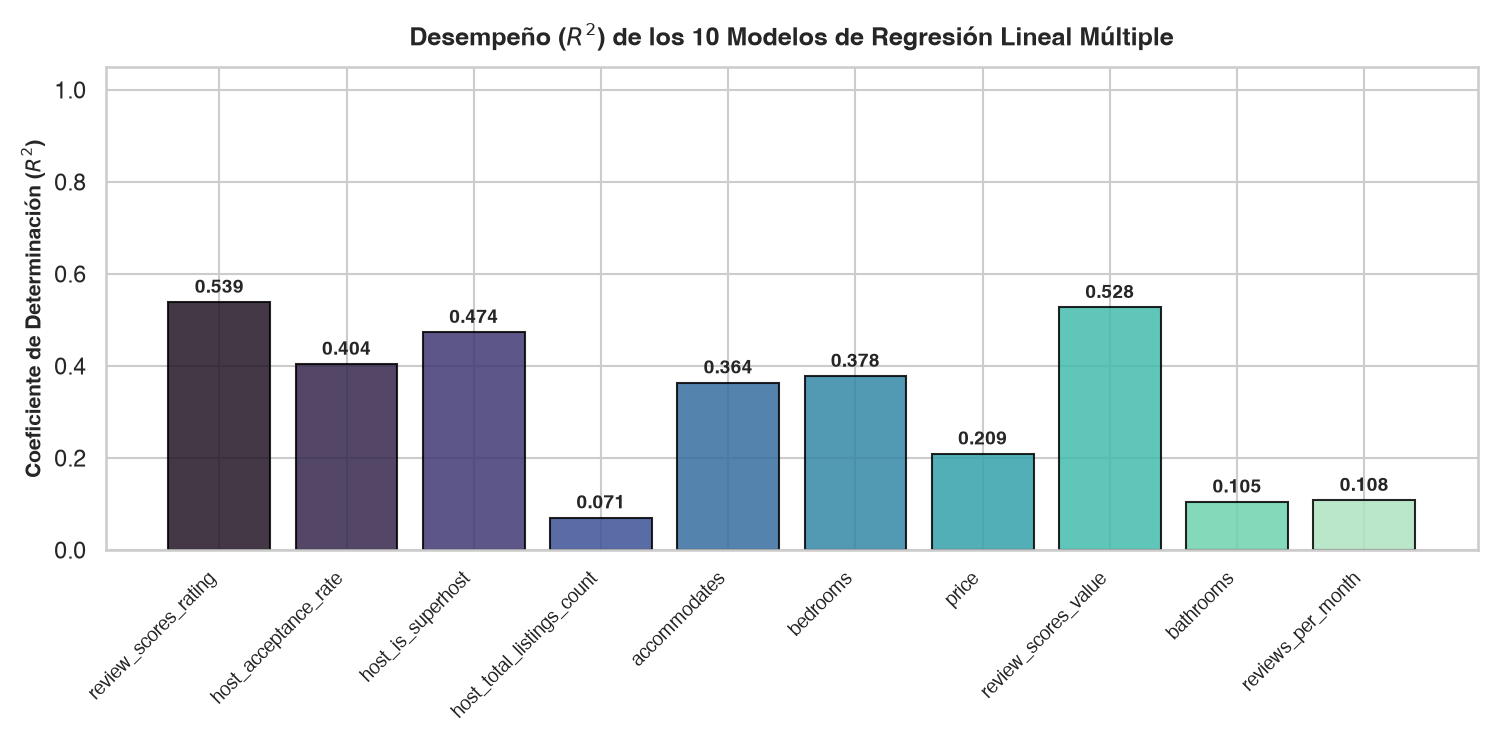

In [22]:
# 6. Tabla Resumen Consolidada de los 10 Modelos Múltiples
resumen_modelos = []
for m in mult_results:
    resumen_modelos.append({
        'Variable Objetivo (y)': m['target'],
        'R^2 (Determinación)': m['r2'],
        'R (Correlación)': m['r'],
        'RMSE': m['rmse'],
        'MAE': m['mae'],
        'Predictor Dominante': m['top_predictor']
    })

df_resumen_modelos = pd.DataFrame(resumen_modelos).sort_values(by='R^2 (Determinación)', ascending=False).reset_index(drop=True)
print(df_resumen_modelos.to_string(index=False))

# Gráfico de barras de R2
plt.figure(figsize=(10, 5))
sns.barplot(data=df_resumen_modelos, x='Variable Objetivo (y)', y='R^2 (Determinación)', palette='mako')
plt.title("Capacidad Predictiva (R^2) de los 10 Modelos de Regresión Múltiple", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


---
## PARTE 4: Conclusiones y Recomendaciones Estratégicas
1. **La Calidad Percibida domina la Reputación:** El modelo múltiple de `review_scores_rating` ($R^2 = 0.5391$) demostró que la variable determinante no es el tamaño del inmueble ni su precio, sino la relación calidad-precio (`review_scores_value`, $\beta = +0.5838$). Anfitriones que superan las expectativas del cliente en relación al monto pagado obtienen puntuaciones superiores.
2. **Determinación del Precio:** El precio de un alojamiento en Boston está fuertemente explicado ($R^2 = 0.2095$) por el estatus de `host_is_superhost` (+89.15 USD en promedio), la capacidad de huéspedes y número de recámaras, demostrando una prima económica sustancial para anfitriones con certificación de excelencia.
3. **Efecto de Escala de los Anfitriones:** Los anfitriones comerciales con múltiples listados (`host_total_listings_count`) sufren una leve penalización en ratings promedio, lo que sugiere que la escala debe acompañarse de sistemas automatizados de atención para mantener estándares de hospitalidad.
4. **Comparativa Multivariada vs Simple:** Los coeficientes de regresión múltiple son sistemáticamente más precisos para la toma de decisiones que las correlaciones bivariadas simples, ya que descuentan la confusión causada por la interdependencia física de los inmuebles (habitaciones, camas, baños).

---
*Fin del Cuaderno de Trabajo. Generado para entrega académica formal.*

